In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
df = pd.read_csv("Student_performance_data _.csv")


In [2]:
df_clean = df.drop(columns=["StudentID"])


In [3]:
print(df_clean.isnull().sum())


Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64


In [7]:
print(df_clean.dtypes)


Age                    int64
Gender                 int64
Ethnicity              int64
ParentalEducation      int64
StudyTimeWeekly      float64
Absences               int64
Tutoring               int64
ParentalSupport        int64
Extracurricular        int64
Sports                 int64
Music                  int64
Volunteering           int64
GPA                  float64
GradeClass           float64
dtype: object


In [59]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
numerical_cols = ["Age", "StudyTimeWeekly", "Absences", "GPA"]
df_clean[numerical_cols] = scaler.fit_transform(df_clean[numerical_cols])


In [61]:
print(df_clean.head())


        Age  Gender  Ethnicity  ParentalEducation  StudyTimeWeekly  Absences  \
0  0.666667       1          0                  2         0.992773  0.241379   
1  1.000000       0          0                  1         0.771270  0.000000   
2  0.000000       0          2                  3         0.210718  0.896552   
3  0.666667       1          0                  3         0.501965  0.482759   
4  0.666667       1          0                  2         0.233840  0.586207   

   Tutoring  ParentalSupport  Extracurricular  Sports  Music  Volunteering  \
0         1                2                0       0      1             0   
1         0                1                0       0      0             0   
2         0                2                0       0      0             0   
3         0                3                1       0      0             0   
4         1                3                0       0      0             0   

        GPA  GradeClass  Cluster  
0  0.732299    

In [63]:
# Apply hierarchical clustering using Ward’s method
Z = linkage(df_clean, method='ward')


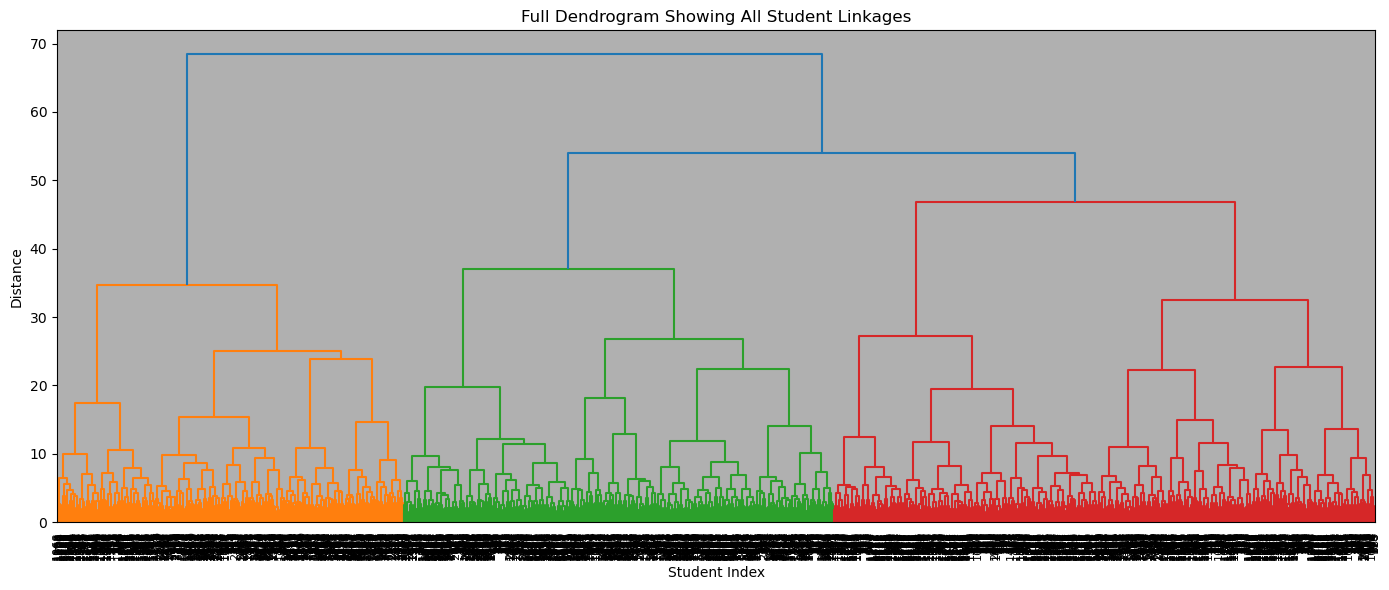

In [65]:
# Full dendrogram
plt.figure(figsize=(14, 6))
dendrogram(Z, leaf_rotation=90., leaf_font_size=8.)
plt.title('Full Dendrogram Showing All Student Linkages')
plt.xlabel('Student Index')
plt.ylabel('Distance')
plt.grid(True)
plt.tight_layout()
plt.show()


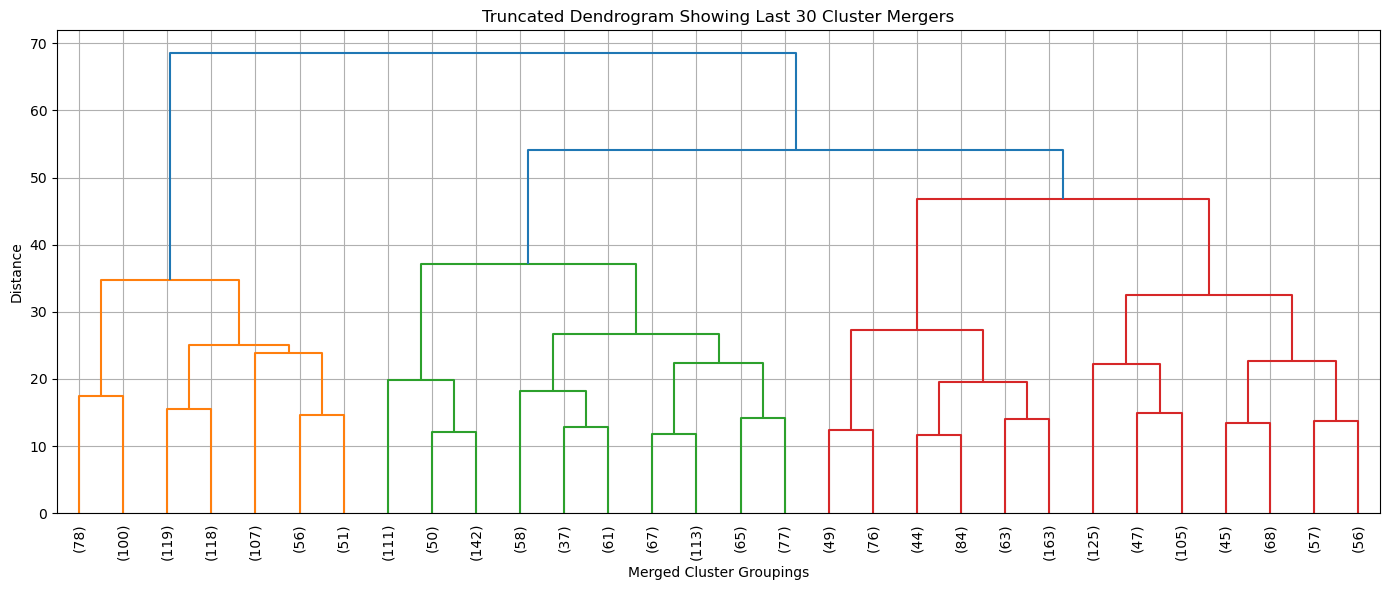

In [41]:
plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=10.)
plt.title('Truncated Dendrogram Showing Last 30 Cluster Mergers')
plt.xlabel('Merged Cluster Groupings')
plt.ylabel('Distance')
plt.grid(True)
plt.tight_layout()
plt.show()


In [32]:
# Create cluster labels with 4 clusters
df_clean['Cluster'] = fcluster(Z, t=4, criterion='maxclust')

           Age  Gender  Ethnicity  ParentalEducation  StudyTimeWeekly  \
0     0.666667       1          0                  2         0.992773   
1     1.000000       0          0                  1         0.771270   
2     0.000000       0          2                  3         0.210718   
3     0.666667       1          0                  3         0.501965   
4     0.666667       1          0                  2         0.233840   
...        ...     ...        ...                ...              ...   
2387  1.000000       1          0                  3         0.534589   
2388  0.666667       0          0                  1         0.379544   
2389  0.333333       1          0                  2         0.340613   
2390  0.333333       1          1                  0         0.621493   
2391  0.333333       1          0                  2         0.891967   

      Absences  Tutoring  ParentalSupport  Extracurricular  Sports  Music  \
0     0.241379         1                2     

In [47]:
df_clean.groupby('Cluster').mean().round(2)

,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
Cluster,,,,,,,,,,,,,,
1,0.48,0.50,0.85,1.74,0.50,0.51,0.28,2.14,0.38,0.29,0.19,0.16,0.47,2.86
2,0.53,0.51,0.91,1.73,0.49,0.48,0.29,2.16,0.38,0.32,0.20,0.15,0.49,2.98
3,0.48,0.53,0.87,1.77,0.47,0.52,0.33,2.05,0.38,0.29,0.19,0.17,0.46,3.19
4,0.46,0.51,0.88,1.75,0.49,0.50,0.33,2.12,0.40,0.32,0.21,0.15,0.49,3.01


In [19]:


score = silhouette_score(df_clean.drop(columns=['Cluster']), df_clean['Cluster'])
print("Silhouette Score (Hierarchical):", round(score, 3))

Silhouette Score (Hierarchical): -0.015
